# experiments/02: Loss Function Comparison — GaussianTransitionNLL vs CombinedTrajectoryLoss

**Experimental question:** Does NLL teacher forcing outperform full-rollout moment matching?

**Controlled variables:** same CRN (birth-death), same encoder (attentive), same architecture, same data.

**Structure:**
1. Configuration
2. Training Data
3. Train — GaussianTransitionNLL (TEACHER_FORCING)
4. Train — CombinedTrajectoryLoss (FULL_ROLLOUT)
5. Training Curves + Timing
6. Learned Dynamics
7. Trajectory Quality
8. Residual Analysis
9. Summary Metrics

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

from _shared.plotting import setup_style, plot_trajectory_ensemble

setup_style()

import time
import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(42)
np.random.seed(42)

## 1. Configuration

Both runs use the **attentive encoder** and differ only in `training_mode`:

| Run | Mode | Loss |
|-----|------|------|
| NLL | `TEACHER_FORCING` | `GaussianTransitionNLL` — no SDE rollout needed |
| Combined | `FULL_ROLLOUT` | `CombinedTrajectoryLoss` — K=8 SDE rollouts per item |

In [2]:
from crn_surrogate.configs.model_config import EncoderConfig, ModelConfig, SDEConfig
from crn_surrogate.configs.training_config import SchedulerType, TrainingConfig, TrainingMode
from crn_surrogate.crn.examples import birth_death, birth_death_analytical
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr

crn        = birth_death(k_birth=2.0, k_death=0.5)
crn_repr   = crn_to_tensor_repr(crn)
analytical = birth_death_analytical(k_birth=2.0, k_death=0.5)

encoder_config = EncoderConfig(d_model=32, n_layers=2, use_attention=True)
sde_config     = SDEConfig.from_crn(crn, d_model=32, d_hidden=64, clip_state=True)
model_config   = ModelConfig(encoder=encoder_config, sde=sde_config)

MAX_EPOCHS = 30

_shared = dict(
    lr=3e-3, max_epochs=MAX_EPOCHS, batch_size=4,
    n_sde_samples=8, n_ssa_samples=16, dt=0.2, val_every=5,
    grad_clip_norm=1.0, scheduler_type=SchedulerType.REDUCE_ON_PLATEAU,
    use_wandb=False,
)
train_cfg_nll  = TrainingConfig(**_shared, training_mode=TrainingMode.TEACHER_FORCING)
train_cfg_comb = TrainingConfig(**_shared, training_mode=TrainingMode.FULL_ROLLOUT)

print(f"NLL run:      {train_cfg_nll.training_mode.value}")
print(f"Combined run: {train_cfg_comb.training_mode.value}, K={train_cfg_comb.n_sde_samples}")

NLL run:      teacher_forcing
Combined run: full_rollout, K=8


## 2. Training Data

In [ ]:
from crn_surrogate.data.dataset import CRNTrajectoryDataset, TrajectoryItem
from crn_surrogate.simulation import GillespieSSA, Trajectory

T_MAX, N_GRID = 15.0, 40
N_WORKERS = 8
M = train_cfg_nll.n_ssa_samples
time_grid  = torch.linspace(0.0, T_MAX, N_GRID)
init_state = torch.tensor([0.0])
ssa        = GillespieSSA()


def make_dataset(n: int) -> CRNTrajectoryDataset:
    items = []
    for _ in range(n):
        trajs = Trajectory.stack_on_grid(
            ssa.simulate_batch(
                stoichiometry=crn.stoichiometry_matrix,
                propensity_fn=crn.evaluate_propensities,
                initial_state=init_state.clone(),
                t_max=T_MAX,
                n_trajectories=M,
                n_workers=N_WORKERS,
            ),
            time_grid,
        )
        items.append(TrajectoryItem(
            crn_repr=crn_repr, initial_state=init_state.clone(),
            trajectories=trajs, times=time_grid,
        ))
    return CRNTrajectoryDataset(items)


train_dataset = make_dataset(60)
val_dataset   = make_dataset(20)
print(f"Train: {len(train_dataset)} items | Val: {len(val_dataset)} items")

## 3. Train — GaussianTransitionNLL (TEACHER_FORCING)

In [4]:
from crn_surrogate.encoder.bipartite_gnn import BipartiteGNNEncoder
from crn_surrogate.simulator.neural_sde import CRNNeuralSDE
from crn_surrogate.training.trainer import Trainer

encoder_nll = BipartiteGNNEncoder(encoder_config)
sde_nll     = CRNNeuralSDE(sde_config, n_species=1)

t0 = time.perf_counter()
result_nll = Trainer(encoder_nll, sde_nll, model_config, train_cfg_nll).train(train_dataset, val_dataset)
elapsed_nll = time.perf_counter() - t0
print(f"\nNLL: {elapsed_nll:.1f}s  ({elapsed_nll / MAX_EPOCHS:.2f}s/epoch)")

Epoch    1 | train=0.7776 | grad=1.692


Epoch    2 | train=0.5788 | grad=0.213


Epoch    3 | train=0.5765 | grad=0.141


Epoch    4 | train=0.5773 | grad=0.216


Epoch    5 | train=0.5775 | val=1.6781 | val_nll=0.5776 | grad=0.202


...

Epoch   26 | train=0.5755 | grad=0.113


Epoch   27 | train=0.5753 | grad=0.109


Epoch   28 | train=0.5757 | grad=0.120


Epoch   29 | train=0.5756 | grad=0.133


Epoch   30 | train=0.5750 | val=1.1391 | val_nll=0.5776 | grad=0.085

NLL: 147.0s  (4.90s/epoch)


## 4. Train — CombinedTrajectoryLoss (FULL_ROLLOUT)

In [5]:
from crn_surrogate.training.losses import CombinedTrajectoryLoss

encoder_comb = BipartiteGNNEncoder(encoder_config)
sde_comb     = CRNNeuralSDE(sde_config, n_species=1)

t0 = time.perf_counter()
result_comb = Trainer(
    encoder_comb, sde_comb, model_config, train_cfg_comb,
    loss_fn=CombinedTrajectoryLoss(var_weight=0.5),
).train(train_dataset, val_dataset)
elapsed_comb = time.perf_counter() - t0
print(f"\nCombined: {elapsed_comb:.1f}s  ({elapsed_comb / MAX_EPOCHS:.2f}s/epoch)")
print(f"Speedup (NLL vs Combined): {elapsed_comb / elapsed_nll:.1f}\u00d7  faster with NLL")

Epoch    1 | train=3.7164 | grad=60.861


Epoch    2 | train=1.0839 | grad=12.127


Epoch    3 | train=0.7348 | grad=4.789


Epoch    4 | train=0.7896 | grad=6.618


Epoch    5 | train=0.8399 | val=0.7121 | val_nll=1.8576 | grad=5.848


...

Epoch   26 | train=0.7464 | grad=4.674


Epoch   27 | train=0.7881 | grad=5.966


Epoch   28 | train=0.7677 | grad=4.629


Epoch   29 | train=0.7500 | grad=4.050


Epoch   30 | train=0.7060 | val=0.7346 | val_nll=288.4232 | grad=3.106

Combined: 1950.0s  (65.00s/epoch)
Speedup (NLL vs Combined): 13.3×  faster with NLL


## 5. Training Curves + Timing

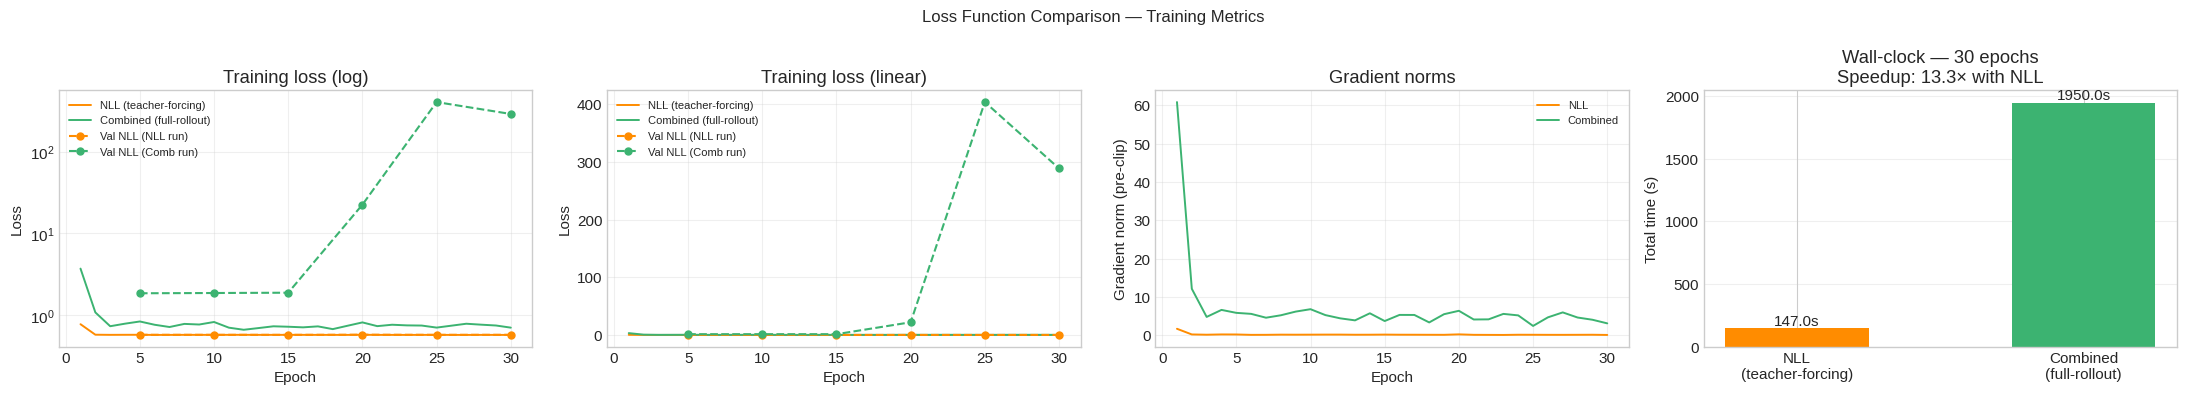

In [6]:
C_NLL  = "darkorange"
C_COMB = "mediumseagreen"
epochs = range(1, MAX_EPOCHS + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for ax, yscale in zip(axes[:2], ["log", "linear"]):
    ax.plot(epochs, result_nll.train_losses,  color=C_NLL,  lw=1.4, label="NLL (teacher-forcing)")
    ax.plot(epochs, result_comb.train_losses, color=C_COMB, lw=1.4, label="Combined (full-rollout)")
    if result_nll.val_nll_losses:
        ax.plot(result_nll.val_epochs,  result_nll.val_nll_losses,
                "o--", color=C_NLL,  markersize=5, label="Val NLL (NLL run)")
        ax.plot(result_comb.val_epochs, result_comb.val_nll_losses,
                "o--", color=C_COMB, markersize=5, label="Val NLL (Comb run)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_yscale(yscale)
    ax.set_title(f"Training loss ({yscale})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

ax = axes[2]
if result_nll.grad_norms:
    ax.plot(epochs, result_nll.grad_norms,  color=C_NLL,  lw=1.4, label="NLL")
    ax.plot(epochs, result_comb.grad_norms, color=C_COMB, lw=1.4, label="Combined")
ax.set_xlabel("Epoch")
ax.set_ylabel("Gradient norm (pre-clip)")
ax.set_title("Gradient norms")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[3]
bars = ax.bar(["NLL\n(teacher-forcing)", "Combined\n(full-rollout)"],
              [elapsed_nll, elapsed_comb], color=[C_NLL, C_COMB], width=0.5)
for bar, val in zip(bars, [elapsed_nll, elapsed_comb]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}s", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Total time (s)")
ax.set_title(f"Wall-clock \u2014 {MAX_EPOCHS} epochs\nSpeedup: {elapsed_comb / elapsed_nll:.1f}\u00d7 with NLL")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Loss Function Comparison \u2014 Training Metrics", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Learned Dynamics

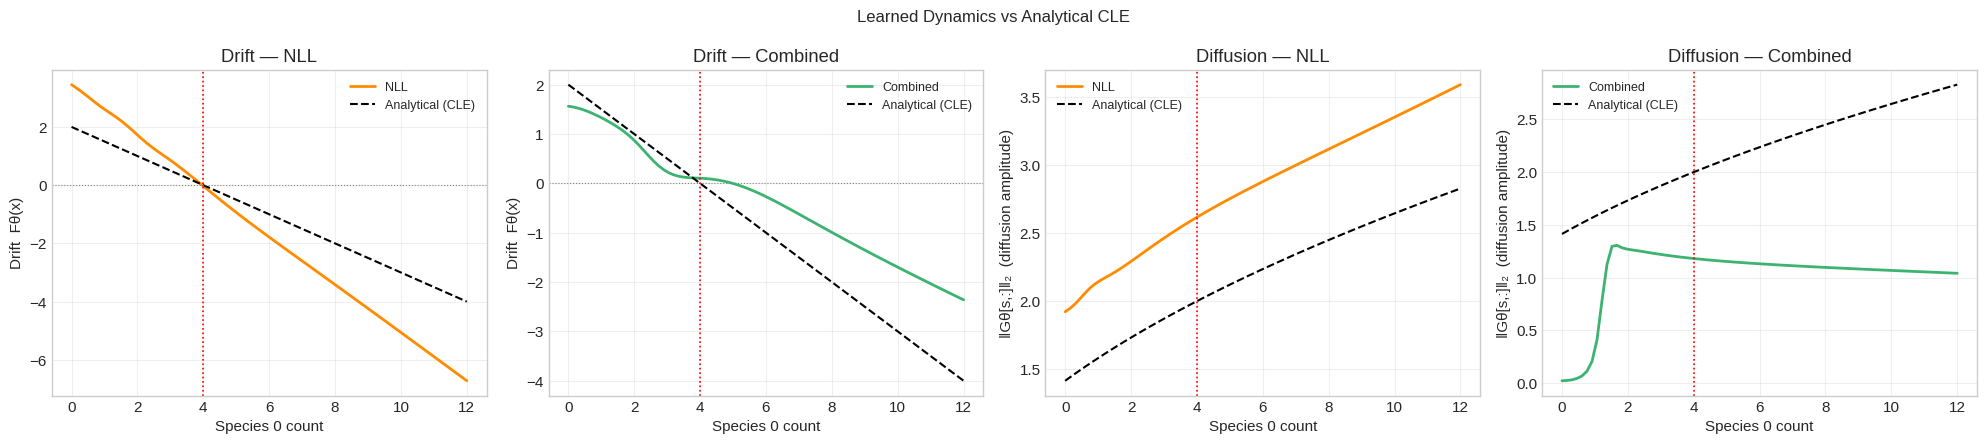

In [7]:
from crn_surrogate.evaluation import DynamicsVisualizer

state_range = torch.linspace(0.0, 12.0, 80)

viz_nll  = DynamicsVisualizer(encoder_nll,  sde_nll,  crn_repr, init_state)
viz_comb = DynamicsVisualizer(encoder_comb, sde_comb, crn_repr, init_state)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

viz_nll.plot_drift(state_range, analytical_drift_fn=analytical["drift"],
                   label="NLL", color=C_NLL, ax=axes[0])
axes[0].set_title("Drift \u2014 NLL")

viz_comb.plot_drift(state_range, analytical_drift_fn=analytical["drift"],
                    label="Combined", color=C_COMB, ax=axes[1])
axes[1].set_title("Drift \u2014 Combined")

viz_nll.plot_diffusion(state_range, analytical_diffusion_fn=analytical["diffusion"],
                       label="NLL", color=C_NLL, ax=axes[2])
axes[2].set_title("Diffusion \u2014 NLL")

viz_comb.plot_diffusion(state_range, analytical_diffusion_fn=analytical["diffusion"],
                        label="Combined", color=C_COMB, ax=axes[3])
axes[3].set_title("Diffusion \u2014 Combined")

for ax in axes:
    ax.axvline(analytical["stationary_mean"], color="red", linestyle=":", lw=1.2)

plt.suptitle("Learned Dynamics vs Analytical CLE", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Trajectory Quality

In [ ]:
from crn_surrogate.evaluation import ModelEvaluator, TrajectoryComparator

eval_times = torch.linspace(0.0, T_MAX, N_GRID)
K_EVAL, M_EVAL = 50, 50

ssa_trajs = Trajectory.stack_on_grid(
    ssa.simulate_batch(
        stoichiometry=crn.stoichiometry_matrix,
        propensity_fn=crn.evaluate_propensities,
        initial_state=init_state.clone(),
        t_max=T_MAX,
        n_trajectories=M_EVAL,
        n_workers=N_WORKERS,
    ),
    eval_times,
)  # (M_EVAL, N_GRID, 1)

sde_trajs_nll  = ModelEvaluator(encoder_nll,  sde_nll,  sde_config).rollout(
    crn_repr, init_state, eval_times, dt=0.1, n_rollouts=K_EVAL)
sde_trajs_comb = ModelEvaluator(encoder_comb, sde_comb, sde_config).rollout(
    crn_repr, init_state, eval_times, dt=0.1, n_rollouts=K_EVAL)

comp_nll  = TrajectoryComparator(sde_trajs_nll,  ssa_trajs, eval_times,
                                 analytical_mean=analytical["stationary_mean"],
                                 analytical_var=analytical["stationary_var"])
comp_comb = TrajectoryComparator(sde_trajs_comb, ssa_trajs, eval_times,
                                 analytical_mean=analytical["stationary_mean"],
                                 analytical_var=analytical["stationary_var"])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (comp, label, color) in enumerate([
    (comp_nll,  "NLL (teacher-forcing)",   C_NLL),
    (comp_comb, "Combined (full-rollout)", C_COMB),
]):
    kw = {"sde_label": label, "sde_color": color}
    comp.plot_mean_std(**kw, ax=axes[row, 0])
    comp.plot_variance(**kw, ax=axes[row, 1])
    comp.plot_sample_paths(**kw, ax=axes[row, 2])
    axes[row, 0].set_title(f"{label} — Mean ± Std")
    axes[row, 1].set_title(f"{label} — Variance")
    axes[row, 2].set_title(f"{label} — Sample Paths")

plt.suptitle(f"Trajectory Quality — {MAX_EPOCHS} epochs", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Residual Analysis

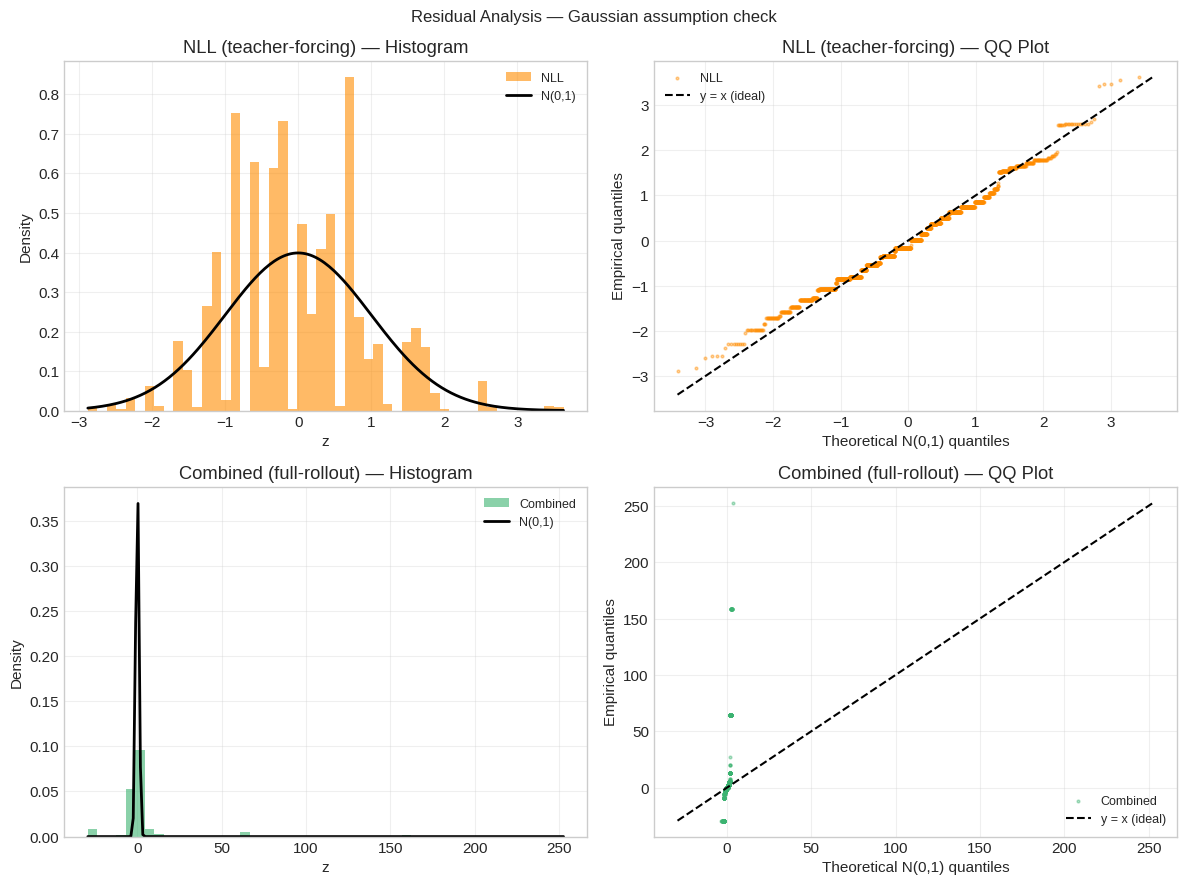

In [9]:
from crn_surrogate.evaluation import ResidualAnalyzer

report_nll  = ResidualAnalyzer(encoder_nll,  sde_nll,  crn_repr).compute_residuals(
    ssa_trajs, eval_times, dt=0.2, initial_state=init_state)
report_comb = ResidualAnalyzer(encoder_comb, sde_comb, crn_repr).compute_residuals(
    ssa_trajs, eval_times, dt=0.2, initial_state=init_state)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ResidualAnalyzer(encoder_nll,  sde_nll,  crn_repr).plot_histogram(
    report_nll,  label="NLL",      color=C_NLL,  ax=axes[0, 0])
ResidualAnalyzer(encoder_nll,  sde_nll,  crn_repr).plot_qq(
    report_nll,  label="NLL",      color=C_NLL,  ax=axes[0, 1])
ResidualAnalyzer(encoder_comb, sde_comb, crn_repr).plot_histogram(
    report_comb, label="Combined", color=C_COMB, ax=axes[1, 0])
ResidualAnalyzer(encoder_comb, sde_comb, crn_repr).plot_qq(
    report_comb, label="Combined", color=C_COMB, ax=axes[1, 1])

for row, label in enumerate(["NLL (teacher-forcing)", "Combined (full-rollout)"]):
    axes[row, 0].set_title(f"{label} \u2014 Histogram")
    axes[row, 1].set_title(f"{label} \u2014 QQ Plot")

plt.suptitle("Residual Analysis \u2014 Gaussian assumption check", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Summary Metrics

In [10]:
print(f"{'Metric':<28} {'NLL':>14} {'Combined':>14}  {'Better':>12}")
print("-" * 72)
for key in ["mean_mse", "var_mse", "final_mean", "final_var", "mean_sde_std"]:
    v_nll  = comp_nll.metrics()[key]
    v_comb = comp_comb.metrics()[key]
    if key in ("mean_mse", "var_mse"):
        better = "NLL" if v_nll < v_comb else "Comb"
    else:
        better = ""
    print(f"{key:<28} {v_nll:>14.4f} {v_comb:>14.4f}  {better:>12}")

print()
print(f"Residual mean (\u21920):  NLL={report_nll.mean[0].item():.3f}  Comb={report_comb.mean[0].item():.3f}")
print(f"Residual std  (\u21921):  NLL={report_nll.std[0].item():.3f}   Comb={report_comb.std[0].item():.3f}")
print(f"Residual kurt (\u21923):  NLL={report_nll.kurtosis[0].item():.2f}   Comb={report_comb.kurtosis[0].item():.2f}")
print()
print(f"Wall-clock:  NLL={elapsed_nll:.1f}s  Combined={elapsed_comb:.1f}s  Speedup={elapsed_comb / elapsed_nll:.1f}\u00d7")

Metric                                  NLL       Combined        Better
------------------------------------------------------------------------
mean_mse                             0.4481         0.1097          Comb
var_mse                              1.7799         2.7282           NLL
final_mean                           4.1331         4.3745              
final_var                            3.6011         2.6468              
mean_sde_std                         1.8656         1.2999              

Residual mean (→0):  NLL=-0.016  Comb=2.093
Residual std  (→1):  NLL=0.930   Comb=20.032
Residual kurt (→3):  NLL=3.31   Comb=44.61

Wall-clock:  NLL=147.0s  Combined=1950.0s  Speedup=13.3×
